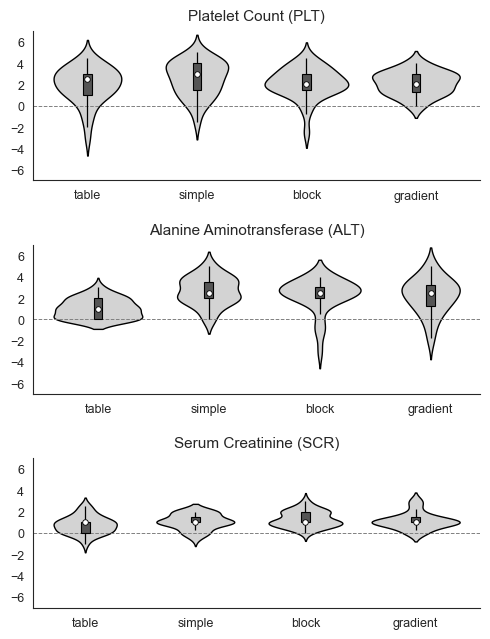

Saved figure1_violin_plots.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("white")

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data_features.csv')

# ── Define test types and display formats ────────────────────────────────────
test_types = {
    'Platelet':   'Platelet Count (PLT)',
    'ALT':        'Alanine Aminotransferase (ALT)',
    'Creatinine': 'Serum Creatinine (SCR)',
}
display_formats = ['table', 'simple', 'block', 'gradient']
display_labels  = ['table', 'simple', 'block', 'gradient']

# Per-subplot y-axis ranges (matching original figure)
ylim_map = {
    'Platelet':   (-10, 10),
    'ALT':        (-10, 10),
    'Creatinine': (-10, 10),
}

# ── Reshape data for plotting ────────────────────────────────────────────────
plot_data = {}
for tt in test_types:
    records = []
    for fmt, label in zip(display_formats, display_labels):
        col = f'{tt}_{fmt}_urgency_diff'
        if col in df.columns:
            for val in df[col].dropna():
                records.append({'Display Format': label, 'Urgency Difference': val})
    plot_data[tt] = pd.DataFrame(records)

# ── Create figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(5, 6.5))

for ax, (tt, title) in zip(axes, test_types.items()):
    data = plot_data[tt]

    # --- Violin bodies (no inner elements) ---
    if len(data) > 0:
        vp = sns.violinplot(
            data=data,
            x='Display Format',
            y='Urgency Difference',
            order=display_labels,
            inner=None,
            color='#D3D3D3',
            linewidth=1.0,
            ax=ax,
            saturation=1.0,
        )
        # Ensure violin outlines are black
        for coll in ax.collections:
            coll.set_edgecolor('black')
            coll.set_linewidth(1.0)

    # --- Manually draw box-plot elements per format ---
    for i, label in enumerate(display_labels):
        subset = data.loc[data['Display Format'] == label, 'Urgency Difference']
        if len(subset) < 2:
            continue

        q1 = np.percentile(subset, 25)
        q3 = np.percentile(subset, 75)
        median = np.median(subset)
        iqr = q3 - q1
        whisker_lo = max(subset.min(), q1 - 1.5 * iqr)
        whisker_hi = min(subset.max(), q3 + 1.5 * iqr)

        box_width = 0.08

        # Whisker lines
        ax.vlines(i, whisker_lo, q1, color='black', linewidth=0.9, zorder=3)
        ax.vlines(i, q3, whisker_hi, color='black', linewidth=0.9, zorder=3)

        # IQR box
        rect = mpatches.FancyBboxPatch(
            (i - box_width / 2, q1), box_width, iqr,
            boxstyle="square,pad=0", facecolor='#555555',
            edgecolor='black', linewidth=0.8, zorder=4,
        )
        ax.add_patch(rect)

        # Median dot (white circle)
        ax.plot(i, median, 'o', color='white', markersize=4,
                markeredgecolor='black', markeredgewidth=0.6, zorder=5)

    # --- Reference line at y=0 ---
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.7, zorder=1)

    # --- Axes styling ---
    ylo, yhi = ylim_map[tt]
    ax.set_ylim(ylo, yhi)
    ax.set_yticks(range(ylo, yhi + 1, 2))
    ax.set_title(title, fontsize=11, fontweight='normal', pad=8)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_ylim(-7,7)
    ax.grid(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout(h_pad=1.5)
plt.savefig('figure1_violin_plots.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved figure1_violin_plots.png")

In [4]:
import pandas as pd
import numpy as np
import json

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('synthetic_data_features.csv')
N = len(df)

def freq(count):
    """Format as 'N (X.X%)'."""
    return f"{count} ({100 * count / N:.1f}%)"

def mean_sd(series):
    """Format as 'X.XX (X.XX)'."""
    return f"{series.mean():.2f} ({series.std():.2f})"

rows = []

# ── AGE ──────────────────────────────────────────────────────────────────────
rows.append({'Characteristic': 'Age', 'Category': '', 'Frequency (%)': '', 'Mean (SD)': mean_sd(df['age'])})

# ── GENDER ───────────────────────────────────────────────────────────────────
gender_cats = ['Male', 'Female', 'Transgender', 'Other/Prefer not to say']
for i, cat in enumerate(gender_cats):
    cnt = (df['gender'] == cat).sum()
    rows.append({
        'Characteristic': 'Gender' if i == 0 else '',
        'Category': cat,
        'Frequency (%)': freq(cnt),
        'Mean (SD)': '',
    })

# ── ETHNICITY ────────────────────────────────────────────────────────────────
eth_cats = [
    ('Hispanic (any race)',    df['ethnicity'].str.contains('Hispanic', na=False) & ~df['ethnicity'].str.contains('Not Hispanic', na=False)),
    ('Not Hispanic or Latino', df['ethnicity'].str.contains('Not Hispanic', na=False)),
]
for i, (cat, mask) in enumerate(eth_cats):
    rows.append({
        'Characteristic': 'Ethnicity' if i == 0 else '',
        'Category': cat,
        'Frequency (%)': freq(mask.sum()),
        'Mean (SD)': '',
    })

# ── RACE ─────────────────────────────────────────────────────────────────────
def parse_race(val):
    if pd.isna(val):
        return []
    try:
        parsed = json.loads(val.replace("'", '"'))
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except (json.JSONDecodeError, AttributeError):
        return [str(val)]

race_exploded = df['race'].apply(parse_race).explode()
race_counts = race_exploded.value_counts()
for i, (cat, cnt) in enumerate(race_counts.items()):
    rows.append({
        'Characteristic': 'Race' if i == 0 else '',
        'Category': cat,
        'Frequency (%)': freq(cnt),
        'Mean (SD)': '',
    })

# ── EDUCATION ────────────────────────────────────────────────────────────────
edu_order = ['High school only', 'Some college', "Bachelor's degree", "Master's degree", 'Doctoral degree']
edu_counts = df['education'].value_counts()
for i, cat in enumerate(edu_order):
    cnt = edu_counts.get(cat, 0)
    rows.append({
        'Characteristic': 'Education' if i == 0 else '',
        'Category': cat,
        'Frequency (%)': freq(cnt),
        'Mean (SD)': '',
    })

# ── HEALTH LITERACY ──────────────────────────────────────────────────────────
hl = df['health_literacy']
for i, val in enumerate(range(1, 6)):
    if val < 5:
        cnt = int(((hl >= val) & (hl < val + 1)).sum())
    else:
        cnt = int((hl >= 5).sum())
    rows.append({
        'Characteristic': 'Health Literacy' if i == 0 else '',
        'Category': str(val),
        'Frequency (%)': freq(cnt),
        'Mean (SD)': mean_sd(hl) if i == 0 else '',
    })

# ── SUBJECTIVE NUMERACY SCALE ───────────────────────────────────────────────
sn = df['subjective_numeracy']
sn_bins = [
    (1, 2, '1-1.99'), (2, 3, '2-2.99'), (3, 4, '3-3.99'),
    (4, 5, '4-4.99'), (5, 6, '5-5.99'), (6, 7, '6'),
]
for i, (lo, hi, label) in enumerate(sn_bins):
    if label == '6':
        cnt = int((sn >= 6).sum())
    else:
        cnt = int(((sn >= lo) & (sn < hi)).sum())
    rows.append({
        'Characteristic': 'Subjective Numeracy Scale' if i == 0 else '',
        'Category': label,
        'Frequency (%)': freq(cnt),
        'Mean (SD)': mean_sd(sn) if i == 0 else '',
    })

# ── GRAPHICAL LITERACY SCALE ────────────────────────────────────────────────
gl = df['graphical_literacy_score']
for i, val in enumerate(range(0, 8)):
    cnt = int((gl == val).sum())
    rows.append({
        'Characteristic': 'Graphical Literacy Scale' if i == 0 else '',
        'Category': str(val),
        'Frequency (%)': freq(cnt),
        'Mean (SD)': mean_sd(gl) if i == 0 else '',
    })

# ── FAMILIARITY WITH MEDICAL TESTS ──────────────────────────────────────────
fam = df['familiarity']
for i, val in enumerate(range(1, 6)):
    cnt = int((fam == val).sum())
    rows.append({
        'Characteristic': 'Familiarity with Medical Tests' if i == 0 else '',
        'Category': str(val),
        'Frequency (%)': freq(cnt),
        'Mean (SD)': mean_sd(fam) if i == 0 else '',
    })

# ── Build and save table ────────────────────────────────────────────────────
table1 = pd.DataFrame(rows, columns=['Characteristic', 'Category', 'Frequency (%)', 'Mean (SD)'])
table1.to_csv('table1_demographics.csv', index=False)
print(table1.to_string(index=False))
print("\nSaved table1_demographics.csv")

                Characteristic                         Category Frequency (%)     Mean (SD)
                           Age                                                46.55 (16.44)
                        Gender                             Male    85 (42.5%)              
                                                         Female   115 (57.5%)              
                                                    Transgender      0 (0.0%)              
                                        Other/Prefer not to say      0 (0.0%)              
                     Ethnicity              Hispanic (any race)    92 (46.0%)              
                                         Not Hispanic or Latino   108 (54.0%)              
                          Race                            Asian    93 (46.5%)              
                                                          White    87 (43.5%)              
                                      Black or African American    35 (17.5%)   

In [5]:
import pandas as pd

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('synthetic_data_features.csv')

# ── Mappings ─────────────────────────────────────────────────────────────────
test_map = {
    'Platelet':   'Platelet Count',
    'ALT':        'ALT',
    'Creatinine': 'Serum Creatinine',
}
fmt_map = {
    'table':    'Table',
    'simple':   'Simple Line',
    'block':    'Blocks Line',
    'gradient': 'Gradient Line',
}

def mean_sd(series):
    s = series.dropna()
    if len(s) == 0:
        return 'N/A'
    return f"{s.mean():.2f} ({s.std():.2f})"

# ── Build rows ───────────────────────────────────────────────────────────────
rows = []
for tt, tt_label in test_map.items():
    for fmt, fmt_label in fmt_map.items():
        near_col = f'{tt}_slightly_{fmt}_urgency'
        extreme_col = f'{tt}_further_{fmt}_urgency'
        diff_col = f'{tt}_{fmt}_urgency_diff'

        near = df[near_col] if near_col in df.columns else pd.Series(dtype=float)
        extreme = df[extreme_col] if extreme_col in df.columns else pd.Series(dtype=float)
        diff = df[diff_col] if diff_col in df.columns else pd.Series(dtype=float)

        diff_valid = diff.dropna()
        pct_zero = f"{100 * (diff_valid == 0).sum() / len(diff_valid):.1f}" if len(diff_valid) > 0 else 'N/A'

        rows.append({
            'Test': tt_label,
            'Display Format': fmt_label,
            'Near-Normal Mean(SD)': mean_sd(near),
            'Extreme Mean(SD)': mean_sd(extreme),
            'Within-Subject Diff Mean(SD)': mean_sd(diff),
            'Difference Equals 0 (%)': pct_zero,
        })

# ── Save ─────────────────────────────────────────────────────────────────────
table2 = pd.DataFrame(rows)
table2.to_csv('table2_urgency.csv', index=False)
print(table2.to_string(index=False))
print("\nSaved table2_urgency.csv")

            Test Display Format Near-Normal Mean(SD) Extreme Mean(SD) Within-Subject Diff Mean(SD) Difference Equals 0 (%)
  Platelet Count          Table          3.21 (1.50)      2.22 (1.37)                 -0.99 (2.16)                     5.9
  Platelet Count    Simple Line          2.63 (1.62)      2.86 (1.60)                  0.23 (2.20)                     9.4
  Platelet Count    Blocks Line          2.66 (1.68)      2.09 (1.51)                 -0.57 (2.33)                     4.0
  Platelet Count  Gradient Line          2.32 (1.60)      2.51 (1.68)                  0.20 (2.38)                     8.7
             ALT          Table          2.47 (1.48)      2.38 (1.69)                 -0.09 (2.57)                     5.9
             ALT    Simple Line          2.65 (1.74)      2.29 (1.45)                 -0.36 (2.26)                     7.5
             ALT    Blocks Line          2.60 (1.52)      2.80 (1.65)                  0.20 (2.22)                     8.0
             ALT